In [330]:
# Imports
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import box
from matplotlib.patches import Patch

In [331]:
df_processed = pd.read_pickle("dataframes/df_processed.pkl")

crime_codes = {
    'ICCS0101': 'Intentional homicide',
    'ICCS0301': 'Sexual violence',
    'ICCS03011': 'Rape',
    'ICCS0401': 'Robbery',
    'ICCS0502': 'Theft',
}

In [332]:
df_cluster = df_processed.groupby('country')[['asylum_per_100k', 'crime_per_100k']].mean()

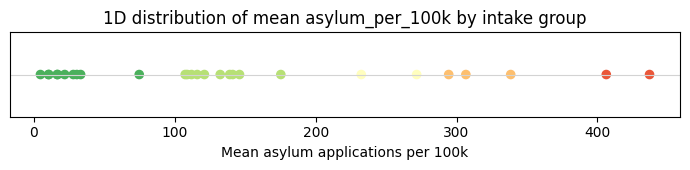

In [333]:
# Country-level clustering on mean asylum applications
scaler_asylum = StandardScaler()
X_asylum = scaler_asylum.fit_transform(df_cluster[["asylum_per_100k"]])

k = 5
kmeans_asylum = KMeans(n_clusters=k, random_state=42)
df_cluster["cluster_asylum_raw"] = kmeans_asylum.fit_predict(X_asylum)

# Relabel clusters so 0 = lowest intake, 4 = highest
means_asylum = (
    df_cluster
    .groupby("cluster_asylum_raw")["asylum_per_100k"]
    .mean()
    .sort_values()
)
label_map_asylum = {old: new for new, old in enumerate(means_asylum.index)}
df_cluster["cluster_asylum"] = df_cluster["cluster_asylum_raw"].map(label_map_asylum)

# Descriptive labels for reporting
label_map_verbose = {
    0: "0 - low",
    1: "1 - medium low",
    2: "2 - medium",
    3: "3 - medium high",
    4: "4 - high",
}
df_cluster["cluster_group"] = df_cluster["cluster_asylum"].map(label_map_verbose)

# 1D plot: mean asylum_per_100k with colour by cluster
base_palette = sns.color_palette("RdYlGn_r", 5)
cluster_colors = {i: base_palette[i] for i in range(5)}

df_plot = df_cluster.reset_index()
x_vals = df_plot["asylum_per_100k"]
y_vals = [0] * len(df_plot)
colors = df_plot["cluster_asylum"].map(cluster_colors)

fig, ax = plt.subplots(figsize=(7, 1.8))
ax.scatter(x_vals, y_vals, c=colors, s=35)

# Visual x-axis line
ax.axhline(0, color="lightgrey", linewidth=0.8)

ax.set_yticks([])
ax.set_ylabel("")
ax.set_xlabel("Mean asylum applications per 100k")
ax.set_title("1D distribution of mean asylum_per_100k by intake group")
plt.tight_layout()
plt.show()

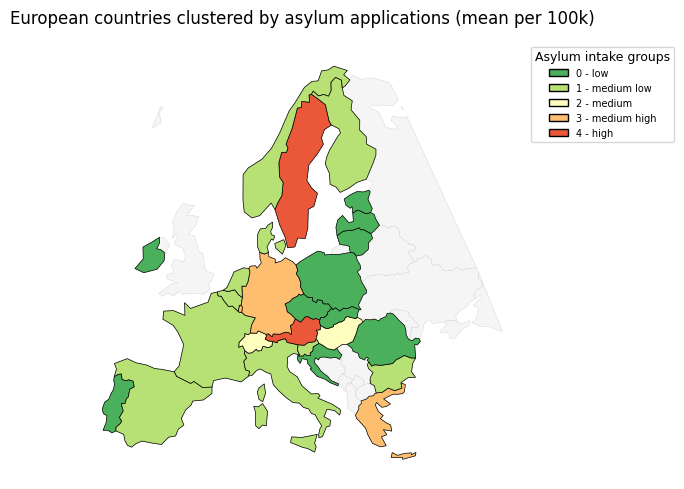

In [334]:
# Map of Europe coloured by asylum intake clusters
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

# Load world country borders and keep Europe
world = gpd.read_file(url)
europe = world[world["CONTINENT"] == "Europe"].copy()

# Clip to a rough Europe bounding box
europe_bbox = box(-15, 30, 40, 72)
europe = gpd.clip(europe, europe_bbox)

# Merge country-level cluster data
df_cluster_reset = df_cluster.reset_index()
gdf = europe.merge(
    df_cluster_reset,
    left_on="NAME",
    right_on="country",
    how="left"
)

# Reproject to a Europe-friendly CRS (ETRS89 / LAEA Europe)
gdf_laea = gdf.to_crs(epsg=3035)

# Colours for cluster indices and labels
base_palette = sns.color_palette('RdYlGn_r', 5)
cluster_colors = {i: base_palette[i] for i in range(5)}
label_map_verbose = {
    0: '0 - low',
    1: '1 - medium low',
    2: '2 - medium',
    3: '3 - medium high',
    4: '4 - high',
}

gdf_laea['cluster_color'] = gdf_laea['cluster_asylum'].map(cluster_colors)
gdf_laea['cluster_group'] = gdf_laea['cluster_asylum'].map(label_map_verbose)

fig, ax = plt.subplots(figsize=(7, 5))
# Background for all European countries
gdf_laea.plot(ax=ax, color="whitesmoke", edgecolor="lightgrey", linewidth=0.3)

# Overlay countries with asylum clusters
gdf_clusters = gdf_laea.dropna(subset=['cluster_asylum']).copy()
gdf_clusters.plot(
    ax=ax,
    color=gdf_clusters['cluster_color'],
    edgecolor='black',
    linewidth=0.5,
    legend=False
)

# Legend with descriptive cluster labels
handles = [
    Patch(facecolor=cluster_colors[i], edgecolor='black', label=label_map_verbose[i])
    for i in range(5)
]
ax.legend(
    handles=handles,
    title='Asylum intake groups',
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=True,
    prop={'size': 7},
    title_fontsize=9,
)

ax.set_title("European countries clustered by asylum applications (mean per 100k)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

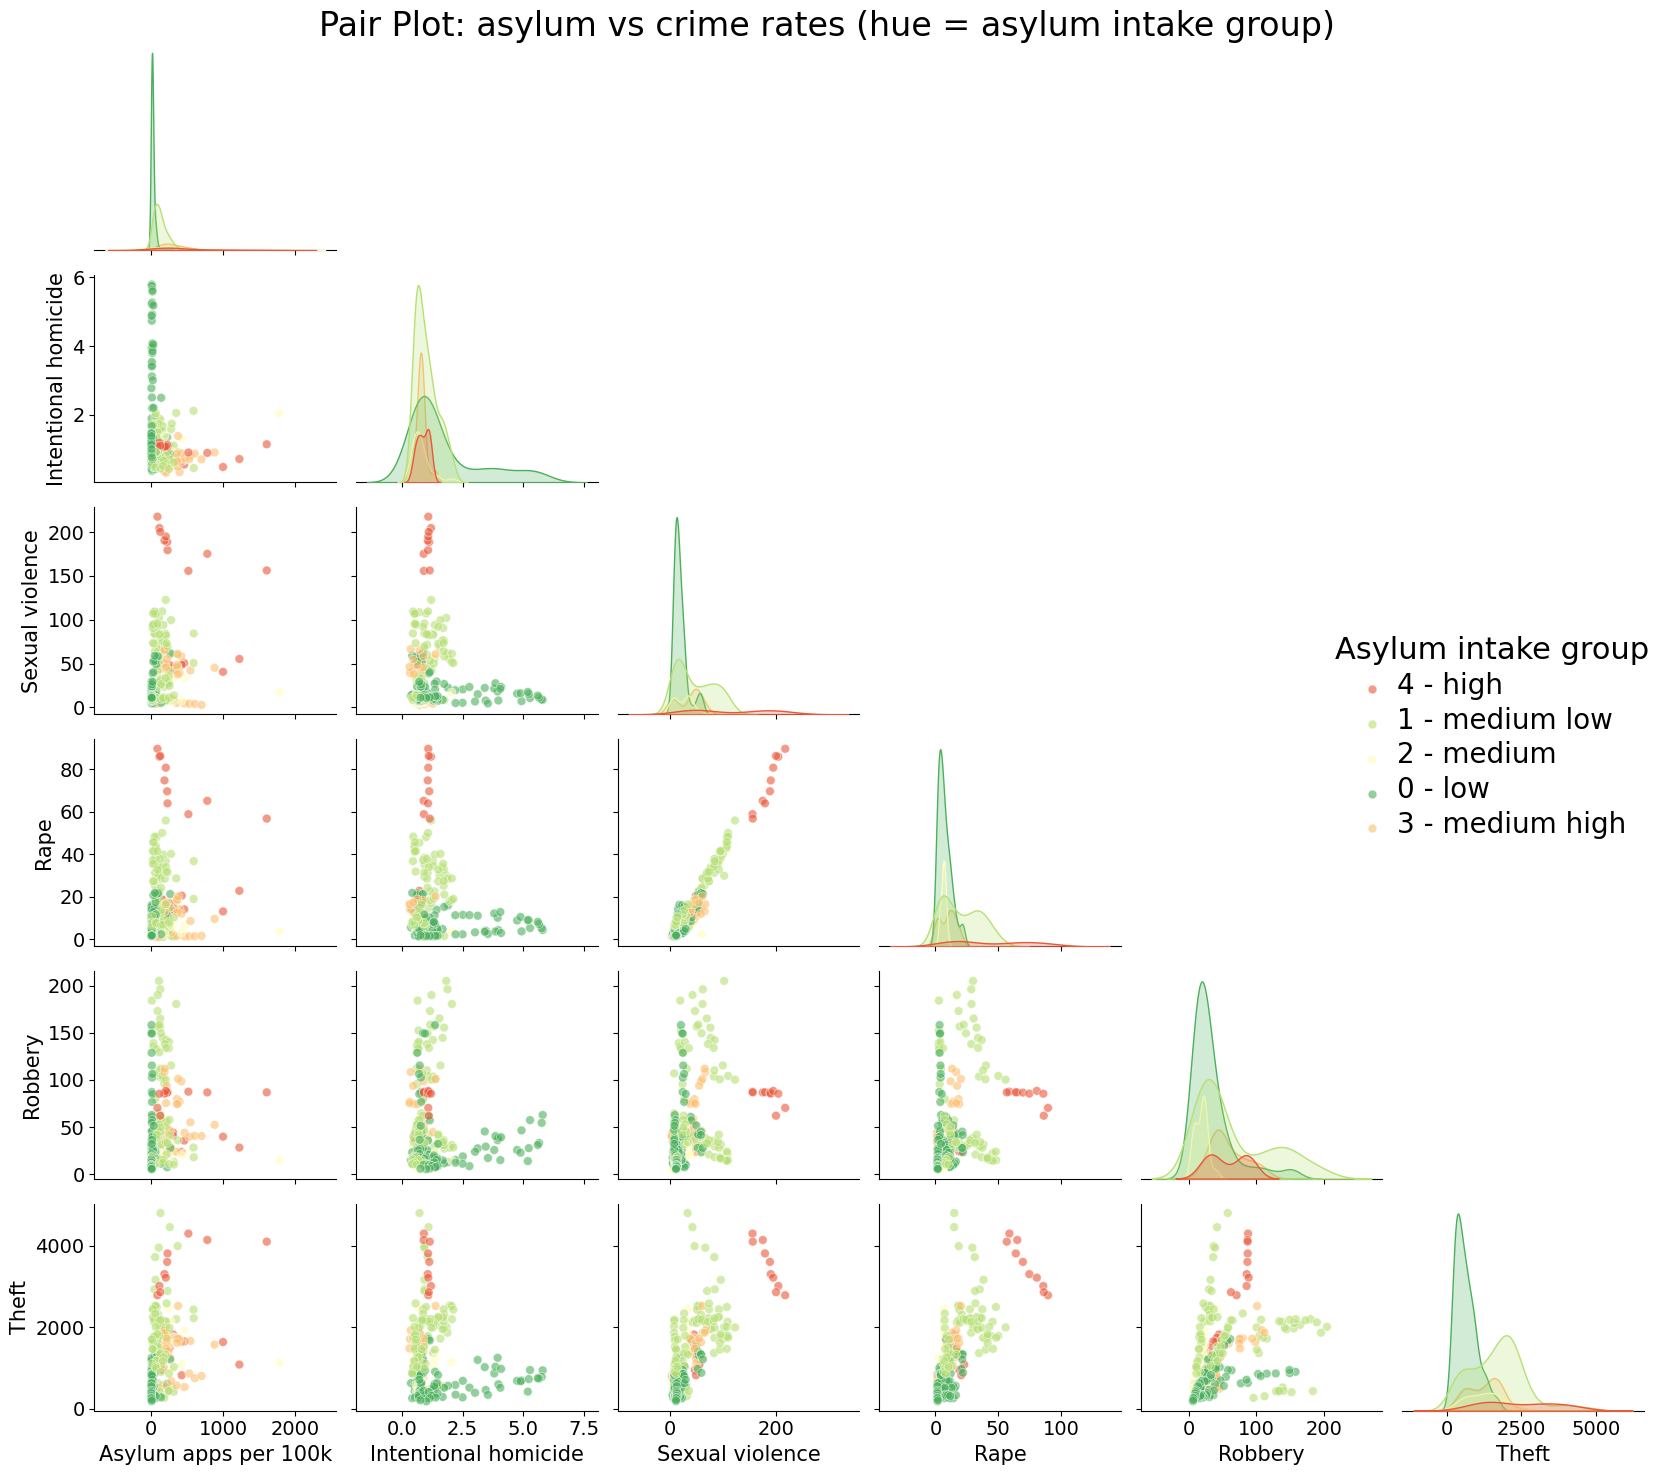

In [338]:
# Pair plot of asylum and crime rates by intake cluster

# Attach clusters back to row-level data
crime_cols = list(crime_codes.keys())
cols_to_plot = ["asylum_per_100k"] + crime_cols

df_pairs = df_processed.merge(
    df_cluster[["cluster_asylum", "cluster_group"]],
    left_on="country",
    right_index=True,
    how="left",
)
df_pairs = df_pairs.dropna(subset=["cluster_asylum"]).copy()
df_pairs["cluster_asylum"] = df_pairs["cluster_asylum"].astype(int)

# Colour mapping that matches the cluster_group labels
label_map_verbose = {
    0: "0 - low",
    1: "1 - medium low",
    2: "2 - medium",
    3: "3 - medium high",
    4: "4 - high",
}
base_palette = sns.color_palette("RdYlGn_r", 5)
cluster_palette = {label_map_verbose[i]: base_palette[i] for i in range(5)}
df_pairs["cluster_group"] = df_pairs["cluster_asylum"].map(label_map_verbose)

# Rename columns so axes show descriptive labels
rename_map = {code: crime_codes.get(code, code) for code in crime_cols}
rename_map["asylum_per_100k"] = "Asylum apps per 100k"
df_pairs_plot = df_pairs[cols_to_plot + ["cluster_group"]].rename(columns=rename_map)

# Pair plot with larger markers and fonts
g = sns.pairplot(
    df_pairs_plot,
    hue="cluster_group",
    palette=cluster_palette,
    corner=True,
    kind="scatter",
    diag_kind="kde",
    plot_kws={"alpha": 0.6, "s": 40},
)

# Enlarge legend text (title and labels)
if hasattr(g, "_legend") and g._legend is not None:
    leg = g._legend
    leg.set_title("Asylum intake group")
    leg.get_title().set_fontsize(22)
    for text in leg.get_texts():
        text.set_fontsize(20)

# Increase axis-label and tick-font sizes
for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(labelsize=14)
        ax.xaxis.label.set_size(15)
        ax.yaxis.label.set_size(15)

g.fig.suptitle(
    "Pair Plot: asylum vs crime rates (hue = asylum intake group)",
    fontsize=24,
)
g.fig.tight_layout()
plt.show()